# Tutorial: simulate one column

This tutorial takes one WACCM column through the full pipeline: from model
profiles, to the aerosol the simulator sees, to simulated ALI measurements,
to the L2 retrieval, which is then compared with the model's own aerosol.

It uses the example column bundled with cesm-hawc, so it needs no CESM
output or orbit files, only the `[sim]` extra:

```bash
pip install cesm-hawc[sim]
```

The first run builds and caches several Mie scattering databases, which takes
a few minutes. The L2 retrieval then takes a few more.

In [1]:
from importlib.resources import files

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import cesm_hawc
from cesm_hawc.constituents import build_waccm_constituents
from cesm_hawc.noise import default_noise_model
from cesm_hawc.orbit_files import l1b_image_to_dataset
from cesm_hawc.simulation import DEFAULT_PRODUCTS, run_ali_simulation_from_profiles

cesm_hawc.configure_environment()

## 1. Load the example column

The example file holds one WACCM column, already interpolated onto a 0–65 km
grid every 1 km: temperature, pressure, trace gases, and the number and
median radius of the MAM4 accumulation (`a1`) and coarse (`a3`) sulfate
modes. It has the same layout as the files `cesm-hawc save-inputs` writes.

To use your own model output instead, set `WACCM_FILE` in the next cell to a
CAM history file. The column nearest `LAT`, `LON` is extracted, saved to
`example_column.nc` in the current directory with the name of the source file
recorded, and used for the rest of the tutorial. Leave `WACCM_FILE` as `None`
to use the bundled example.

In [ ]:
# A CAM history file to extract the column from, or None for the bundled example.
WACCM_FILE = None   # e.g. "/path/to/case.cam.h0.2035-02.nc"
LAT, LON = 30.6, 180.0
TIME_INDEX = 0

if WACCM_FILE is None:
    column_path = files("cesm_hawc") / "data" / "example_column.nc"
else:
    from pathlib import Path

    from cesm_hawc.waccm import WACCMAtmosphere

    column_path = Path("example_column.nc")
    WACCMAtmosphere(WACCM_FILE).save_column_profiles(
        LAT, LON, str(column_path), time_index=TIME_INDEX
    )

    # Record which history file the column came from.
    column = xr.load_dataset(column_path)
    column.attrs["source_file"] = Path(WACCM_FILE).name
    column.to_netcdf(column_path)

Saved example_column.nc  (22 KB)


In [3]:
ds = xr.open_dataset(column_path)

# The same dictionary WACCMAtmosphere.get_column_profiles() returns.
profiles = {"altitudes_m": ds["altitude_m"].values}
profiles.update({name: da.values for name, da in ds.data_vars.items()})
profiles["sulfate_a1_sigma"] = float(ds.attrs["sigma_a1"])
profiles["sulfate_a3_sigma"] = float(ds.attrs["sigma_a3"])

alt_m = profiles["altitudes_m"]
lat, lon = float(ds.attrs["latitude"]), float(ds.attrs["longitude"])
ds

<xarray.Dataset> Size: 7kB
Dimensions:            (altitude_m: 66)
Coordinates:
  * altitude_m         (altitude_m) float64 528B 0.0 1e+03 ... 6.4e+04 6.5e+04
Data variables:
    pressure_pa        (altitude_m) float64 528B 1.018e+05 9.122e+04 ... 9.377
    temperature_k      (altitude_m) float64 528B 292.0 283.8 ... 222.9 220.4
    specific_humidity  (altitude_m) float64 528B 0.009906 0.007999 ... 4.125e-06
    vmr_o3             (altitude_m) float64 528B 4.933e-08 ... 3.324e-07
    vmr_no2            (altitude_m) float64 528B 5.017e-11 ... 1.999e-12
    vmr_h2o            (altitude_m) float64 528B 0.01593 0.01285 ... 6.631e-06
    vmr_so2            (altitude_m) float64 528B 5.342e-11 ... 9.313e-11
    n_air_cm3          (altitude_m) float64 528B 2.525e+19 ... 3.083e+15
    sulfate_a1_N_cm3   (altitude_m) float64 528B 222.1 231.1 ... 1e-06 1e-06
    sulfate_a1_r_um    (altitude_m) float64 528B 0.06511 0.06591 ... 0.001 0.001
    sulfate_a3_N_cm3   (altitude_m) float64 528B 0.9369 0.7439 ... 1e-06 1e-06
    sulfate_a3_r_um    (altitude_m) float64 528B 0.1744 0.1887 ... 0.001 0.001
Attributes:
    latitude:     30.6
    longitude:    180.0
    time_index:   0
    sigma_a1:     1.6
    sigma_a3:     1.2
    description:  WACCM column profiles from cesm-hawc
    source_file:  sai_1.0Tg_2030_001.cam.h2.2030-04-30-00000.nc

## 2. Look at the sulfate aerosol

Each mode is described by its number concentration and lognormal median
radius at every altitude.

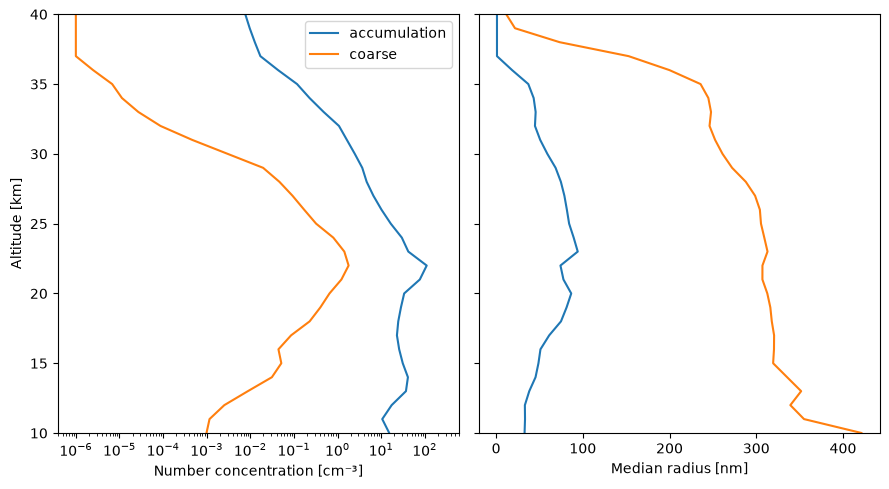

In [4]:
alt_km = alt_m / 1e3
fig, (ax_n, ax_r) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
for mode, label in [("a1", "accumulation"), ("a3", "coarse")]:
    ax_n.semilogx(profiles[f"sulfate_{mode}_N_cm3"], alt_km, label=label)
    ax_r.plot(profiles[f"sulfate_{mode}_r_um"] * 1e3, alt_km, label=label)
ax_n.set(xlabel="Number concentration [cm⁻³]", ylabel="Altitude [km]", ylim=(10, 40))
ax_r.set(xlabel="Median radius [nm]")
ax_n.legend()
fig.tight_layout()

## 3. Build the simulator's atmosphere

`build_waccm_constituents` converts the profiles into `sasktran2`
constituents: WACCM ozone and NO₂, and one aerosol constituent per sulfate
mode, each with a Mie database matched to that mode's width. With
`return_extinction=True` it also returns the resulting extinction, the
"truth" the retrieval will be compared against.

In [5]:
wavelengths_nm = np.array([470.0, 745.0, 1020.0])

constituents, true_ext = build_waccm_constituents(
    profiles, alt_m, return_extinction=True, truth_wavelengths_nm=wavelengths_nm
)
sorted(constituents)

['aerosol_accum', 'aerosol_coarse', 'no2', 'o3']

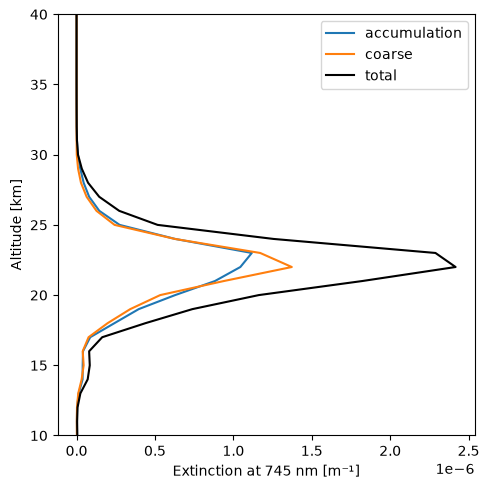

In [6]:
i745 = int(np.argmin(np.abs(wavelengths_nm - 745.0)))
truth_745 = (true_ext["aerosol_accum_extinction_per_m"][i745]
             + true_ext["aerosol_coarse_extinction_per_m"][i745])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(true_ext["aerosol_accum_extinction_per_m"][i745], alt_km, label="accumulation")
ax.plot(true_ext["aerosol_coarse_extinction_per_m"][i745], alt_km, label="coarse")
ax.plot(truth_745, alt_km, "k", label="total")
ax.set(xlabel="Extinction at 745 nm [m⁻¹]", ylabel="Altitude [km]", ylim=(10, 40))
ax.legend()
fig.tight_layout()

## 4. Simulate the ALI observation and retrieval

The simulator needs the viewing geometry: here a fixed tangent point (the
column's location) and fixed solar angles. The noise model is seeded so this
notebook gives the same result every time it is run.

The retrieval prints its progress; we capture it to check that it
converged.

In [7]:
import contextlib
import io

from cesm_hawc.convergence import parse_scipy_convergence

sim_geometry = {
    "tangent_latitude": lat,
    "tangent_longitude": lon,
    "tangent_solar_zenith_angle": 60.0,
    "tangent_solar_azimuth_angle": 0.0,
    "altitude_grid": alt_m,
    "polarization_states": ["I", "dolp"],
    "sample_wavelengths": wavelengths_nm,
    "time": pd.Timestamp("2035-02-01T12:00:00Z"),
}

log = io.StringIO()
with contextlib.redirect_stdout(log):
    data = run_ali_simulation_from_profiles(
        profiles, alt_m, sim_geometry,
        products=DEFAULT_PRODUCTS,
        noise_model=default_noise_model(seed=0),
    )
parse_scipy_convergence(log.getvalue())

{'converged': True, 'termination_reason': 'ftol', 'n_function_evaluations': 32}

## 5. The simulated measurements (L1b)

ALI measures limb radiance and its degree of linear polarization (DoLP) at
each tangent altitude. `l1b_image_to_dataset` collects them, with their
noise, into one dataset.

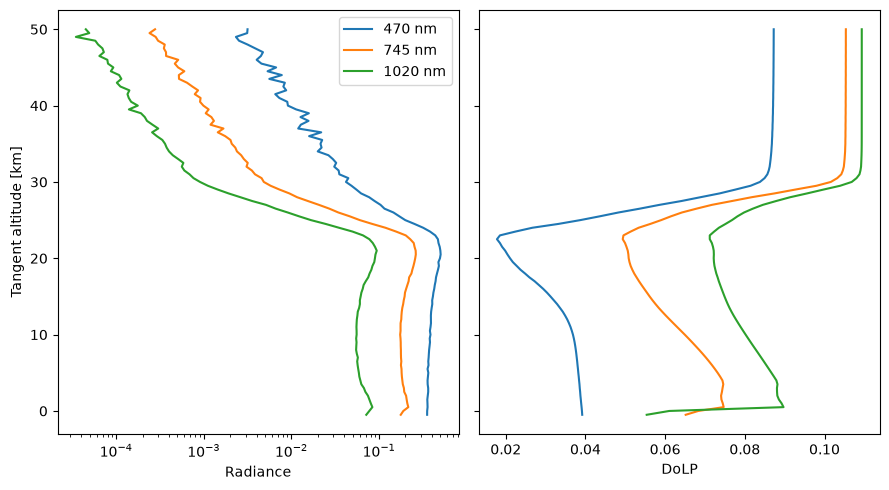

In [8]:
l1b = l1b_image_to_dataset(data["l1b"], wavelengths_nm)

fig, (ax_i, ax_p) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
for wl in l1b["wavelength"].values:
    sel = l1b.sel(wavelength=wl)
    ax_i.semilogx(sel["radiance"], sel["altitude_m"] / 1e3, label=f"{wl:.0f} nm")
    ax_p.plot(sel["dolp"], sel["altitude_m"] / 1e3)
ax_i.set(xlabel="Radiance", ylabel="Tangent altitude [km]")
ax_p.set(xlabel="DoLP")
ax_i.legend()
fig.tight_layout()

## 6. Compare the retrieval with the model truth

The L2 retrieval estimates aerosol extinction at 745 nm and a single median
radius at each altitude. Unlike the model, which has two sulfate modes, the
retrieval assumes one lognormal mode with a width of 1.6.

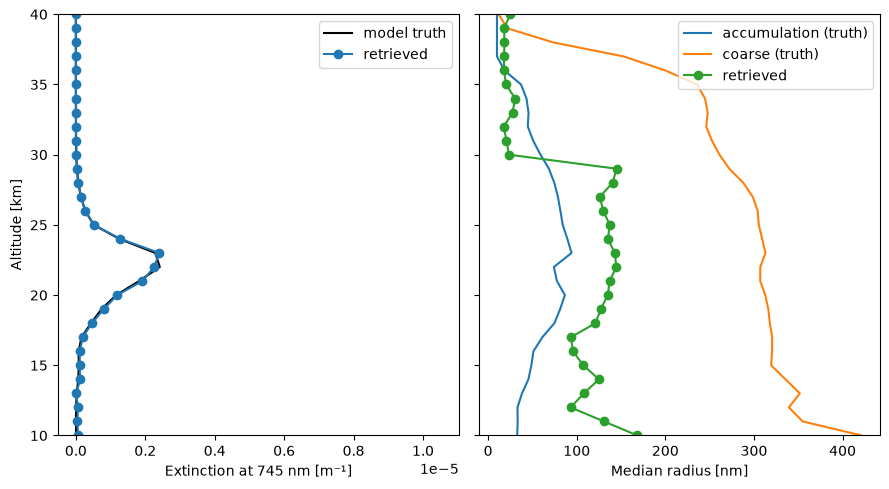

In [9]:
l2 = data["l2"]
ret_ext = l2["stratospheric_aerosol_extinction_per_m"]
ret_r = l2["stratospheric_aerosol_median_radius"]

fig, (ax_e, ax_r) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
ax_e.plot(truth_745, alt_km, "k", label="model truth")
ax_e.plot(ret_ext.values, ret_ext["altitude"].values / 1e3, "o-", label="retrieved")
ax_e.set(xlabel="Extinction at 745 nm [m⁻¹]", ylabel="Altitude [km]", ylim=(10, 40))
ax_e.legend()

for mode, label in [("aerosol_accum", "accumulation (truth)"), ("aerosol_coarse", "coarse (truth)")]:
    ax_r.plot(true_ext[f"{mode}_median_radius_nm"], alt_km, label=label)
ax_r.plot(ret_r.values, ret_r["altitude"].values / 1e3, "o-", label="retrieved")
ax_r.set(xlabel="Median radius [nm]")
ax_r.legend()
fig.tight_layout()

## Next steps

- Run the same steps on your own model output from the command line with
  `cesm-hawc run --mode fixed`; see the [Quickstart](quickstart.md).
- Sample along a real HAWC orbit with `--mode orbit`; see
  [Run modes](user-guide/run-modes.md).
- `examples/quickstart.py` in the repository repeats this tutorial with real
  orbit geometry and a CESM history file, and checks that a file saved by
  `save-inputs` reproduces the same retrieval.